<a href="https://colab.research.google.com/github/PinillaDiego/Algoritmos-de-Optimizaci-n-2026/blob/main/Trabajo_Pr%C3%A1ctico_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Diego Pinilla Forero  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/1DwWfL7GlJ6dO-fzO_05ePK6E1u4pPPrq?usp=sharing <br>
Problema:
>1. Sesiones de doblaje <br>


Descripción del problema:


• Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en
las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el
estudio de grabación independientemente del número de tomas que se graben. No es
posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de
manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los
datos son:
Número de actores: 10
Número de tomas : 30
Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario

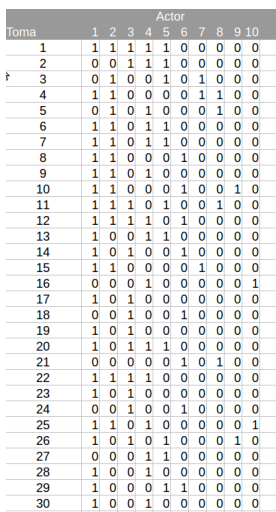





                                        

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

El problema se deben asignar 30 tomas de grabación a varios días de trabajo, con un máximo de 6 tomas por día.

Una solución se representa como una lista de días y cada día contiene una lista de tomas

Un ejemplode solución seria:

Dia1 = t1,t2,t3,t4,t5,t6<br>
Dia2 = t7,t8,t9,t10,t11,t12<br>
Dia3 = t13,t14,t15,t16,t17,t18<br>
Dia4 = t19,t20,t21,t22,t23,t24<br>
Dia5 = t25,t26,t27,t28,t29,t30<br>

Cada toma tiene información sobre qué actores participan, representado en la matriz dada donde el valor de 1 representa el actor participa en la toma y 0 el actor no participa. <br><br>

El objetivo es minimizar la cantidad total de actores distintos que deben asistir cada día para reducir los costos, por lo cual se podria representar la función de esta forma: <br>
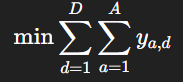 <br>

donde Ya,d indica si el actor a participa en el día d <br><br>

Restricciones:<br>
Cada toma se graba solo una vez <br>
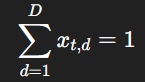 <br><br>
Máximo de tomas por día <br>
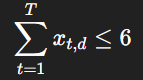<br><br>

Variables binarias <br>
image.png



In [ ]:
# MATRIZ DE DATOS (30 tomas × 10 actores)
M = [
[1,1,1,1,1,0,0,0,0,0],
[0,0,1,1,1,0,0,0,0,0],
[0,1,0,0,1,0,1,0,0,0],
[1,1,0,0,0,0,1,1,0,0],
[0,1,0,1,0,0,0,1,0,0],
[1,1,0,1,1,0,0,0,0,0],
[1,1,0,1,1,0,0,0,0,0],
[1,1,0,0,0,1,0,0,0,0],
[1,1,0,1,0,0,0,0,0,0],
[1,1,0,0,0,1,0,0,1,0],
[1,1,1,0,1,0,0,1,0,0],
[1,1,1,1,0,0,0,0,0,0],
[1,0,0,1,1,0,0,0,0,0],
[1,0,1,0,0,1,0,0,0,0],
[1,1,0,0,0,0,1,0,0,0],
[0,0,0,1,0,0,0,0,0,1],
[1,0,1,0,0,0,0,0,0,0],
[0,0,1,0,0,1,0,0,0,0],
[1,0,1,0,0,0,0,0,0,0],
[1,0,1,1,1,0,0,0,0,0],
[0,0,0,0,0,1,0,1,0,0],
[1,1,1,1,0,0,0,0,0,0],
[1,0,1,0,0,0,0,0,0,0],
[0,0,1,0,0,1,0,0,0,0],
[1,1,0,1,0,0,0,0,0,1],
[1,0,1,0,1,0,0,0,0,0],
[0,0,0,1,1,0,0,0,0,0],
[1,0,0,1,0,0,0,0,0,0],
[1,0,0,0,1,1,0,0,0,0],
[1,0,0,1,0,0,0,0,0,0],
]


N_TOMAS = 30                # Total de tomas a grabar
N_ACTORES = 10              # Numero de actores de doblaje
MAX_TOMAS_DIA = 6           # Maximo de tomas por día


# Devuelve cuántos actores distintos aparecen en total en esas tomas.
def actores_distintos_del_dia(lista_tomas):
    # Se crea un vector de 10 ceros, uno por actor
    presente = [0] * N_ACTORES

    # Ciclo para cada toma en el día
    for t in lista_tomas:
        # Ciclo para cada actor
        for a in range(N_ACTORES):
            # Condicional si el actor participa en la toma, se marca como 1 si se encuentra en la toma
            if M[t][a] == 1:
                presente[a] = 1

    # Cuenta actores estan marcados (suma de 1's)
    total = 0
    for a in range(N_ACTORES):
        total += presente[a]
    return total


# Calcula el costo total de un plan (suma de actores distintos por día)
def costo_total(plan):
    total = 0
    # Se suma el costo de cada día
    for dia in plan:
        total += actores_distintos_del_dia(dia)
    return total


# Generador numerico POSIX rand (genera valores entre 0 y 1

semilla = 3

def pseudo_random():
    global semilla
    semilla = (semilla * 1103515245 + 12345) % 2147483648  # 2^31
    return semilla / 2147483648

# Mezcla una lista aleatoriamente usando el algoritmo de Fisher-Yates y nuestro generador pseudoaleatorio
def mezclar_lista(lista):
    n = len(lista)
    # Recorremo la lista desde el final hasta el principio
    for i in range(n-1, 0, -1):
        # Generamos un índice aleatorio entre 0 y el valor de i
        j = int(pseudo_random() * (i + 1))
        # Intercambia los elementos en las posiciones i y j
        lista[i], lista[j] = lista[j], lista[i]

# Greedy procesa las tomas en el orden dado
def greedy_con_orden(tomas_orden):
    # Inicia con 6 días vacios
    plan = [[] for _ in range(6)]

    # Procesa cada toma en el orden dado
    for t in tomas_orden:
        mejor_dia = -1
        mejor_aumento = 999999  # Número muy grande

        # Prueba cada día
        for d in range(6):
            # Si el día ya está lleno, no se puede poner más tomas
            if len(plan[d]) >= MAX_TOMAS_DIA:
                continue

            # Calcula actores distintos antes de añadir la toma
            antes = actores_distintos_del_dia(plan[d])

            # Prueba añadir la toma
            plan[d].append(t)
            despues = actores_distintos_del_dia(plan[d])

            # Retira la toma
            plan[d].pop()

            # Calcula cuántos actores nuevos añadir en la toma
            aumento = despues - antes

            # Si el día es mejor que los anteriores, se guarda
            if aumento < mejor_aumento:
                mejor_aumento = aumento
                mejor_dia = d

        # Asigna la toma al mejor día encontrado
        plan[mejor_dia].append(t)

    return plan

# Prueba muchos ordenes distintos de tomas y se queda con el de menor costo

mejor_costo = 999999
mejor_plan = None

print("BUSCANDO MEJOR ORDEN...\n")

# Probar con 10000 ordenes distintos
for intento in range(10000):
    # Se crea la lista de tomas (del 0 al 29)
    tomas = list(range(N_TOMAS))

    # Se mezcla de forma aleatoriamente
    mezclar_lista(tomas)

    # Se ejecuta greedy con este orden
    plan = greedy_con_orden(tomas)

    # Calcula el costo
    costo = costo_total(plan)

    # Si es mejor que otro ya procesado, se guarda
    if costo < mejor_costo:
        mejor_costo = costo
        mejor_plan = plan
        print(f"Intento {intento}: nuevo mejor costo = {costo}")

print("\nMEJOR SOLUCION ENCONTRADA")
print(f"Costo total: {mejor_costo}")
print(f"(Número de días: {len(mejor_plan)})")

for i, dia in enumerate(mejor_plan):
    tomas_mostrar = [t + 1 for t in sorted(dia)]
    actores = actores_distintos_del_dia(dia)
    print(f"Día {i+1}: {tomas_mostrar} | actores = {actores}")

BUSCANDO MEJOR ORDEN...

Intento 0: nuevo mejor costo = 37
Intento 6: nuevo mejor costo = 33
Intento 155: nuevo mejor costo = 32
Intento 2613: nuevo mejor costo = 31

MEJOR SOLUCION ENCONTRADA
Costo total: 31
(Número de días: 6)
Día 1: [13, 14, 17, 19, 27, 29] | actores = 5
Día 2: [9, 12, 15, 18, 23, 24] | actores = 6
Día 3: [6, 7, 16, 22, 25, 28] | actores = 6
Día 4: [3, 4, 8, 10, 21, 30] | actores = 8
Día 5: [1, 2, 5, 11, 20, 26] | actores = 6
Día 6: [] | actores = 0


#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

El espacio de soluciones es extremadamente grande si se distribuyen 30 tomas en 5 días con máximo 6 por día, esto nos daria 30!/(6!)elevado a la 5 por lo cual no esposible evaluar todas las posibles soluciones requiriendo metodos heuristicos para hallar el aproximado

#Diseño
- ¿Que técnica utilizo? ¿Por qué?

En una primera instancia se utilizo tecnica Voraz tomando decisiones basadas únicamente en la mejor opción local en cada paso, sin embargo, esta no garantiza encontrar el optimo global.
En seguida se utilizó el metodo GRASP (Greedy Randomized Adaptive Search Procedure) la cual nos permite:<br>

Generar permutaciones aleatorias de tomas<br>
Construir solución asignando cada toma al mejor día<br>
Múltiples reinicios<br>